In [1]:
!pip install opencv-python scikit-learn matplotlib kagglehub

In [2]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [4]:
print(os.listdir(path))
print(os.listdir(path + "/chest_xray"))
print(os.listdir(path + "/chest_xray/train"))

['chest_xray']
['chest_xray', '__MACOSX', 'val', 'test', 'train']
['PNEUMONIA', 'NORMAL']


In [6]:
IMG_SIZE = 128

def load_data(data_dir):
    data = []
    labels = []

    categories = ["NORMAL", "PNEUMONIA"]

    for category in categories:
        path_cat = os.path.join(data_dir, category)
        class_num = categories.index(category)

        for img in os.listdir(path_cat):
            try:
                img_path = os.path.join(path_cat, img)
                img_array = cv2.imread(img_path)

                if img_array is None:
                    continue

                img_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                data.append(img_array)
                labels.append(class_num)

            except:
                pass

    data = np.array(data) / 255.0
    labels = np.array(labels)

    return data, labels


data, labels = load_data(path + "/chest_xray/train")

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Data shape: (5216, 128, 128, 3)
Labels shape: (5216,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

In [12]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 4,879,681 (18.61 MB)

 Trainable params: 2,621,697 (10.00 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 54s 275ms/step - accuracy: 0.9377 - loss: 0.2766 - val_accuracy: 0.9607 - val_loss: 0.1458
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9825 - loss: 0.0484 - val_accuracy: 0.9617 - val_loss: 0.1260
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9878 - loss: 0.0325 - val_accuracy: 0.9732 - val_loss: 0.1100
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9959 - loss: 0.0153 - val_accuracy: 0.9741 - val_loss: 0.1090
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9820 - loss: 0.0626 - val_accuracy: 0.9693 - val_loss: 0.1542


In [14]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 147ms/step
Confusion Matrix:
[[262  25]
 [  7 750]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       287
           1       0.97      0.99      0.98       757

    accuracy                           0.97      1044
   macro avg       0.97      0.95      0.96      1044
weighted avg       0.97      0.97      0.97      1044



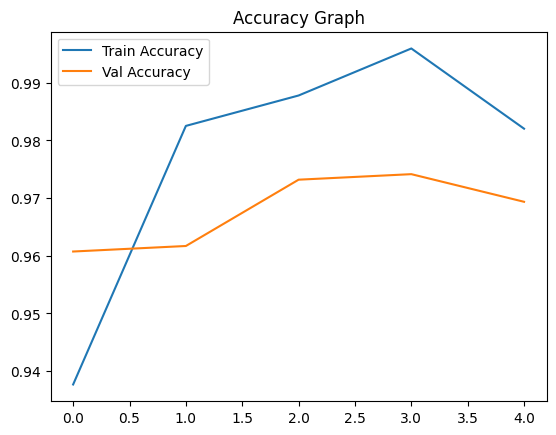

In [15]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

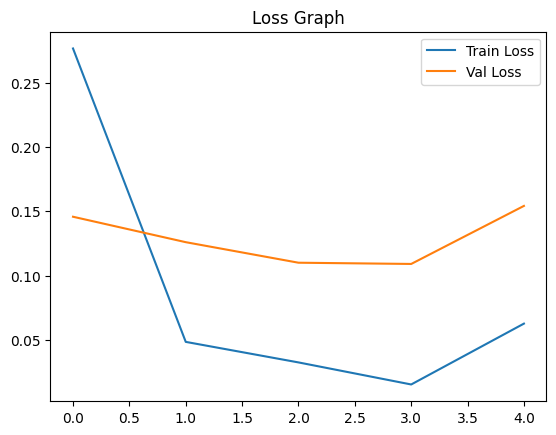

In [16]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

In [17]:
model.save("medical_model.h5")

In [19]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return f"Error: Could not load image at {img_path}"

    # Use IMG_SIZE (128) to match the trained model
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = np.reshape(img, (1, IMG_SIZE, IMG_SIZE, 3))

    prediction = model.predict(img)

    return "PNEUMONIA" if prediction > 0.5 else "NORMAL"

# Ensure you have a valid image path here
result = predict_image("/content/test.jpg")
print("Prediction:", result)

Prediction: Error: Could not load image at /content/test.jpg


In [20]:
import glob

# Get a sample image from the test set
test_images = glob.glob(path + "/chest_xray/test/PNEUMONIA/*.jpeg")
if test_images:
    sample_path = test_images[0]
    print(f"Testing with image: {sample_path}")
    result = predict_image(sample_path)
    print("Prediction:", result)
else:
    print("No test images found.")

Testing with image: /kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person1676_virus_2892.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
Prediction: PNEUMONIA


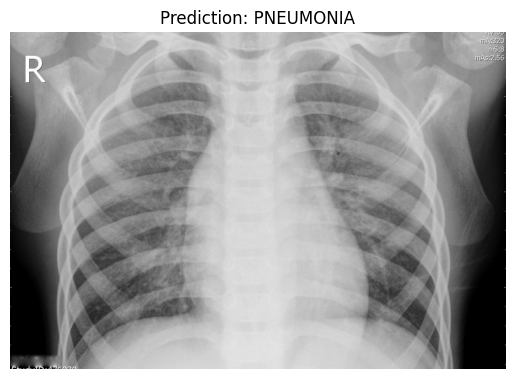

In [23]:
# Use the sample_path we found in the previous cell
img = cv2.imread(sample_path)

if img is not None:
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Prediction: {result}")
    plt.axis('off')
    plt.show()
else:
    print(f"Could not load image at {sample_path}")